<a href="https://colab.research.google.com/github/AngellyC07/Ciencia_de_datos/blob/main/PROYECTO_CUADERNO_2_AN%C3%81LISIS_DE_DATOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
#librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [79]:
#Cargar el dataset
df = pd.read_csv("/content/lol_ranked_player_data.csv")

In [80]:
df.head()

,date,weekday,champion,lane,role,kills,deaths,assists,kda,gold,damage,cs,vision,game_duration,cs_per_min,gold_per_min,damage_per_min,win
0,2026-03-14 20:13:53.106,Saturday,Nautilus,BOTTOM,SUPPORT,2,5,24,5.200000,10340,13613,37,76,2027,1.095215,306.068081,402.950173,0
1,2026-03-14 19:27:15.432,Saturday,Annie,BOTTOM,DUO,4,6,12,2.666667,10360,29954,146,37,2039,4.296224,304.855321,881.432075,0
2,2026-03-14 18:45:23.590,Saturday,Malzahar,MIDDLE,SOLO,9,3,6,5.000000,15983,43805,261,35,2055,7.620438,466.656934,1278.978102,1
3,2026-02-28 20:19:17.404,Saturday,Mel,NONE,SUPPORT,0,3,0,0.000000,4642,3502,117,8,911,7.705818,305.729967,230.647640,0
4,2026-02-28 19:43:36.541,Saturday,Smolder,BOTTOM,CARRY,12,3,8,6.666667,14279,18404,202,33,1744,6.949541,491.250000,633.165138,1


In [81]:
print("Total de partidas analizadas:", len(df))

Total de partidas analizadas: 101


##Taxonomía de los datos

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            101 non-null    object 
 1   weekday         101 non-null    object 
 2   champion        101 non-null    object 
 3   lane            101 non-null    object 
 4   role            101 non-null    object 
 5   kills           101 non-null    int64  
 6   deaths          101 non-null    int64  
 7   assists         101 non-null    int64  
 8   kda             101 non-null    float64
 9   gold            101 non-null    int64  
 10  damage          101 non-null    int64  
 11  cs              101 non-null    int64  
 12  vision          101 non-null    int64  
 13  game_duration   101 non-null    int64  
 14  cs_per_min      101 non-null    float64
 15  gold_per_min    101 non-null    float64
 16  damage_per_min  101 non-null    float64
 17  win             101 non-null    int

In [83]:
df.dtypes

,0
date,object
weekday,object
champion,object
lane,object
role,object
kills,int64
deaths,int64
assists,int64
kda,float64
gold,int64


##Descripción Estadística (Métricas)


In [84]:
df.describe()

,kills,deaths,assists,kda,gold,damage,cs,vision,game_duration,cs_per_min,gold_per_min,damage_per_min,win
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,5.009901,4.821782,9.029703,4.401292,11819.495050,21176.574257,108.574257,31.534653,1808.811881,3.552011,382.774975,640.862547,0.613861
std,3.955996,3.576020,6.035653,4.249914,5074.376497,12640.184350,74.868331,21.260087,625.580494,2.308486,71.742174,275.981924,0.489291
min,0.000000,0.000000,0.000000,0.000000,515.000000,0.000000,0.000000,0.000000,107.000000,0.000000,259.842520,0.000000,0.000000
25%,2.000000,2.000000,4.000000,1.571429,9109.000000,12200.000000,43.000000,18.000000,1590.000000,1.480263,315.984427,440.905660,0.000000
50%,4.000000,4.000000,8.000000,3.142857,11608.000000,19867.000000,85.000000,26.000000,1819.000000,2.866397,380.823328,654.102307,1.000000
75%,7.000000,7.000000,13.000000,5.333333,14497.000000,28848.000000,167.000000,41.000000,2256.000000,5.641953,439.791469,842.104265,1.000000
max,20.000000,15.000000,24.000000,22.000000,26806.000000,53132.000000,313.000000,97.000000,3100.000000,8.601845,548.407080,1278.978102,1.000000


In [85]:
#Media ponderada
champ_stats = df.groupby("champion").agg(
    games=("win","count"),
    winrate=("win","mean")
)


weighted_winrate = (champ_stats["winrate"] * champ_stats["games"]).sum() / champ_stats["games"].sum()

print("Winrate ponderado:", weighted_winrate)

Winrate ponderado: 0.6138613861386139


In [86]:
#Varianza
df["kills"].var()

15.649900990099008

In [87]:
#Desviación estándar
df["kills"].std()

3.9559955750858733

In [88]:
#Rango
df["kills"].max() - df["kills"].min()

20

In [89]:
#Cuartiles
df["kills"].quantile([0.25,0.5,0.75])

,kills
0.25,2.0
0.50,4.0
0.75,7.0


In [90]:
#IQR (Rango intercuartil)
Q1 = df["kills"].quantile(0.25)
Q3 = df["kills"].quantile(0.75)

IQR = Q3 - Q1

print("IQR:", IQR)


IQR: 5.0


In [91]:
#Detección de outliers
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df["kills"] < lower) | (df["kills"] > upper)]

print("Outliers encontrados:", len(outliers))


Outliers encontrados: 2


#Gráficas

In [100]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#**ANÁLISIS DE LAS PARTIDAS**

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("/content/lol_ranked_player_data.csv")

df.head()

,date,weekday,champion,lane,role,kills,deaths,assists,kda,gold,damage,cs,vision,game_duration,cs_per_min,gold_per_min,damage_per_min,win
0,2026-03-14 20:13:53.106,Saturday,Nautilus,BOTTOM,SUPPORT,2,5,24,5.200000,10340,13613,37,76,2027,1.095215,306.068081,402.950173,0
1,2026-03-14 19:27:15.432,Saturday,Annie,BOTTOM,DUO,4,6,12,2.666667,10360,29954,146,37,2039,4.296224,304.855321,881.432075,0
2,2026-03-14 18:45:23.590,Saturday,Malzahar,MIDDLE,SOLO,9,3,6,5.000000,15983,43805,261,35,2055,7.620438,466.656934,1278.978102,1
3,2026-02-28 20:19:17.404,Saturday,Mel,NONE,SUPPORT,0,3,0,0.000000,4642,3502,117,8,911,7.705818,305.729967,230.647640,0
4,2026-02-28 19:43:36.541,Saturday,Smolder,BOTTOM,CARRY,12,3,8,6.666667,14279,18404,202,33,1744,6.949541,491.250000,633.165138,1


#¿Qué campeones utiliza con mayor frecuencia el jugador?

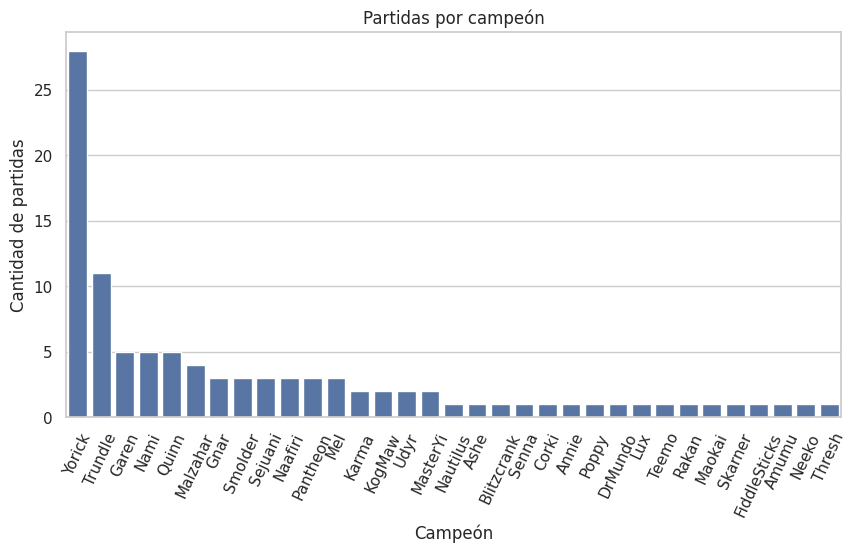

In [130]:
champ_counts = df["champion"].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=champ_counts.index, y=champ_counts.values)

plt.title("Partidas por campeón")
plt.xlabel("Campeón")
plt.ylabel("Cantidad de partidas")
plt.xticks(rotation=65)

plt.show()

#Winrate ponderado de campeón por impacto de partidas

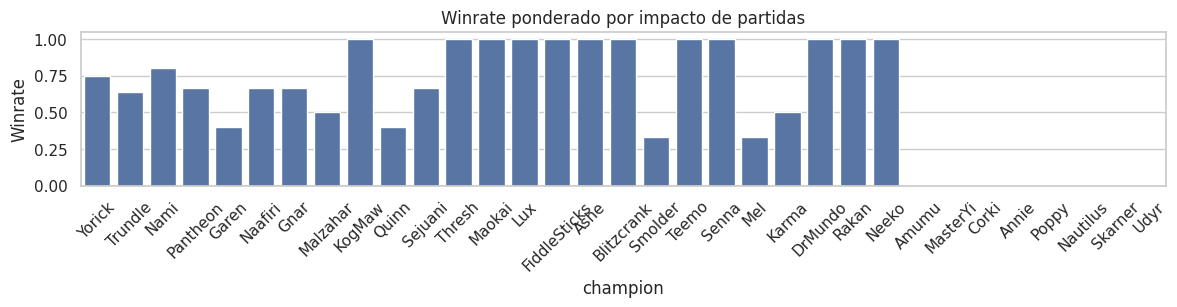

              wins  games   winrate  impact
champion                                   
Yorick          21     28  0.750000    21.0
Trundle          7     11  0.636364     7.0
Nami             4      5  0.800000     4.0
Pantheon         2      3  0.666667     2.0
Garen            2      5  0.400000     2.0
Naafiri          2      3  0.666667     2.0
Gnar             2      3  0.666667     2.0
Malzahar         2      4  0.500000     2.0
KogMaw           2      2  1.000000     2.0
Quinn            2      5  0.400000     2.0
Sejuani          2      3  0.666667     2.0
Thresh           1      1  1.000000     1.0
Maokai           1      1  1.000000     1.0
Lux              1      1  1.000000     1.0
FiddleSticks     1      1  1.000000     1.0
Ashe             1      1  1.000000     1.0
Blitzcrank       1      1  1.000000     1.0
Smolder          1      3  0.333333     1.0
Teemo            1      1  1.000000     1.0
Senna            1      1  1.000000     1.0
Mel              1      3  0.333

In [149]:
champ_stats = df.groupby("champion").agg(
    wins=("win","sum"),
    games=("win","count")
)

champ_stats["winrate"] = champ_stats["wins"] / champ_stats["games"]

# impacto ponderado
champ_stats["impact"] = champ_stats["winrate"] * champ_stats["games"]

champ_stats = champ_stats.sort_values("impact", ascending=False)

plt.figure(figsize=(14,2))

sns.barplot(
    x=champ_stats.index,
    y=champ_stats["winrate"]
)

plt.title("Winrate ponderado por impacto de partidas")
plt.ylabel("Winrate")
plt.xticks(rotation=45)

plt.show()

print(champ_stats)

#Análisis específico del campeón principal Yorick

Número de partidas

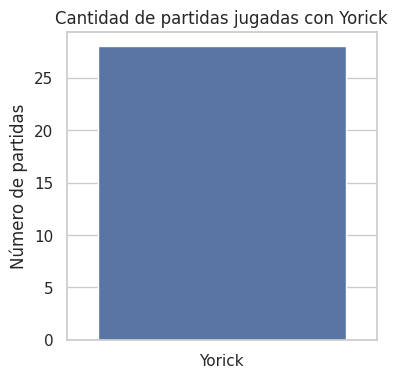

In [154]:
df_yorick = df[df["champion"] == "Yorick"]

yorick_games = len(df_yorick)

plt.figure(figsize=(4,4))

sns.barplot(
    x=["Yorick"],
    y=[yorick_games]
)

plt.title("Cantidad de partidas jugadas con Yorick")
plt.ylabel("Número de partidas")

plt.show()

Distribución de kills

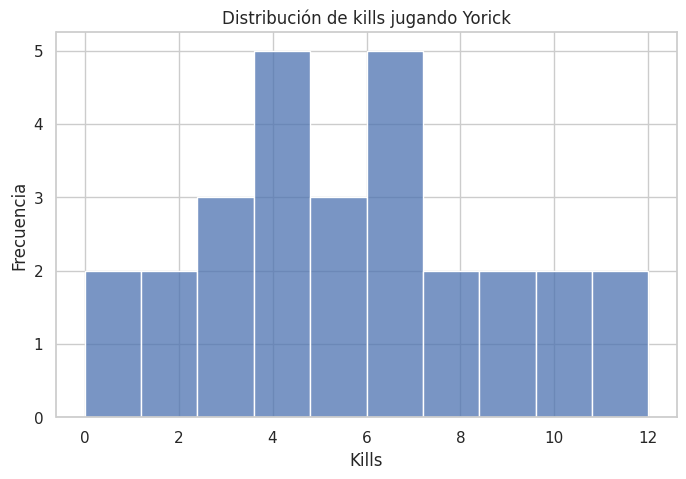

In [155]:
plt.figure(figsize=(8,5))

sns.histplot(df_yorick["kills"], bins=10)

plt.title("Distribución de kills jugando Yorick")
plt.xlabel("Kills")
plt.ylabel("Frecuencia")

plt.show()

Clasificación de estilo de juego

/tmp/ipykernel_1555/3891266075.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_yorick["estilo"] = df_yorick["kills"].apply(estilo_juego)


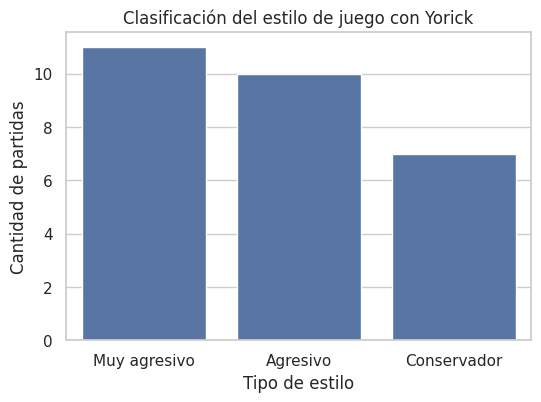

In [175]:
def estilo_juego(kills):
    if kills <= 3:
        return "Conservador"
    elif kills <= 6:
        return "Agresivo"
    else:
        return "Muy agresivo"

df_yorick["estilo"] = df_yorick["kills"].apply(estilo_juego)

estilo_counts = df_yorick["estilo"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=estilo_counts.index,
    y=estilo_counts.values
)

plt.title("Clasificación del estilo de juego con Yorick")
plt.xlabel("Tipo de estilo")
plt.ylabel("Cantidad de partidas")

plt.show()

¿Matar para ganar? / ¿Cómo cambia la probabilidad de victoria según la cantidad de kills?

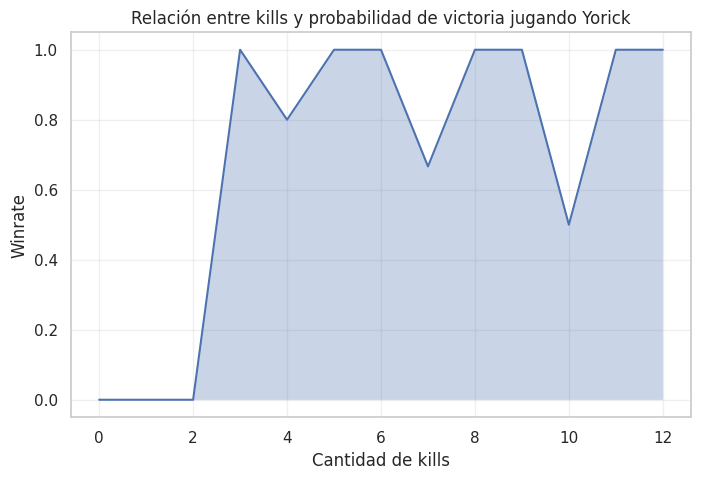

In [203]:
# Calcular winrate según cantidad de kills
winrate_by_kills = df_yorick.groupby("kills")["win"].mean()

plt.figure(figsize=(8,5))

sns.lineplot(
    x=winrate_by_kills.index,
    y=winrate_by_kills.values
)

plt.fill_between(
    winrate_by_kills.index,
    winrate_by_kills.values,
    alpha=0.3
)

plt.title("Relación entre kills y probabilidad de victoria jugando Yorick")
plt.xlabel("Cantidad de kills")
plt.ylabel("Winrate")

plt.grid(alpha=0.3)

plt.show()

¿Cómo se distribuyen las kills en partidas ganadas y perdidas?

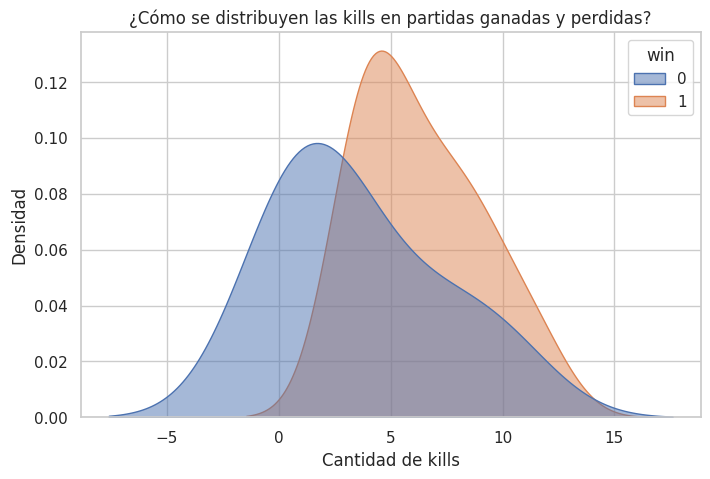

In [202]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_yorick,
    x="kills",
    hue="win",
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("¿Cómo se distribuyen las kills en partidas ganadas y perdidas?")
plt.xlabel("Cantidad de kills")
plt.ylabel("Densidad")

plt.show()

¿Matar más significa ganar más partidas?

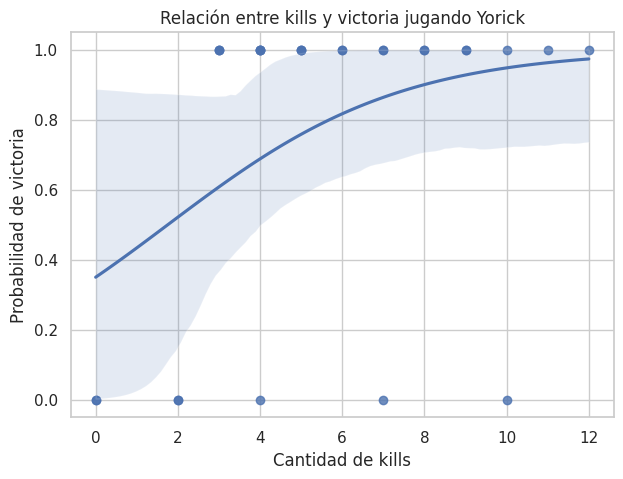

In [159]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df_yorick,
    x="kills",
    y="win",
    logistic=True
)

plt.title("Relación entre kills y victoria jugando Yorick")
plt.xlabel("Cantidad de kills")
plt.ylabel("Probabilidad de victoria")

plt.show()

¿Cómo se distribuye el KDA del jugador en sus partidas con Yorick?

/tmp/ipykernel_1555/134979531.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_yorick["kda"] = (df_yorick["kills"] + df_yorick["assists"]) / df_yorick["deaths"].replace(0,1)


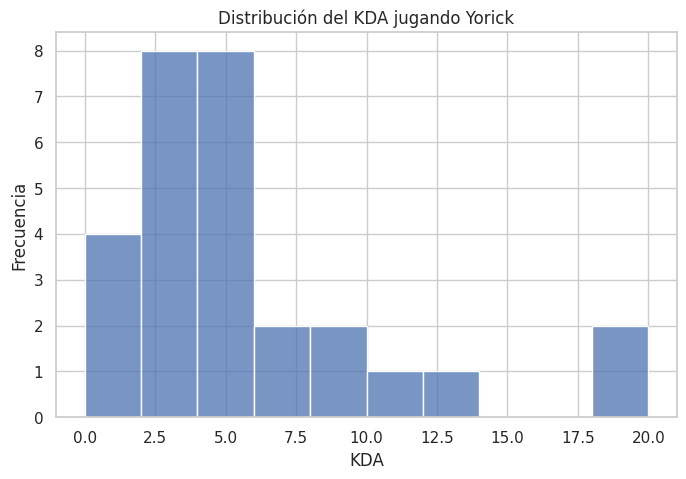

In [160]:
# Calcular KDA
df_yorick["kda"] = (df_yorick["kills"] + df_yorick["assists"]) / df_yorick["deaths"].replace(0,1)

# Histograma del KDA
plt.figure(figsize=(8,5))

sns.histplot(df_yorick["kda"], bins=10)

plt.title("Distribución del KDA jugando Yorick")
plt.xlabel("KDA")
plt.ylabel("Frecuencia")

plt.show()

¿Morir más está relacionado con perder partidas?

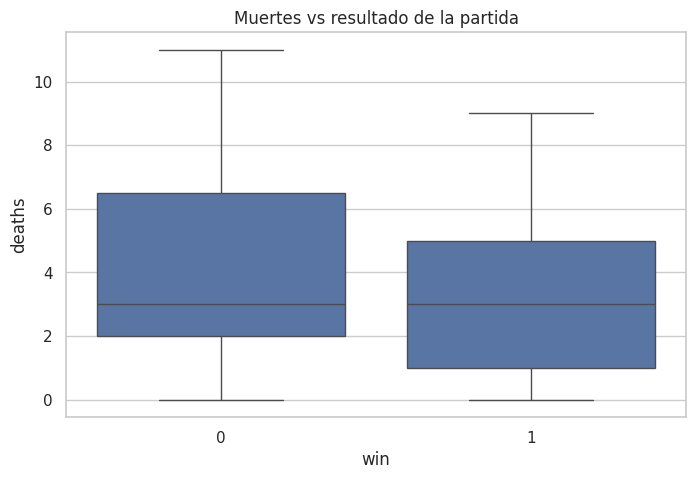

In [161]:
plt.figure(figsize=(8,5))

sns.boxplot(x="win", y="deaths", data=df_yorick)

plt.title("Muertes vs resultado de la partida")

plt.show()

¿Existe relación entre el daño infligido y las eliminaciones del jugador?

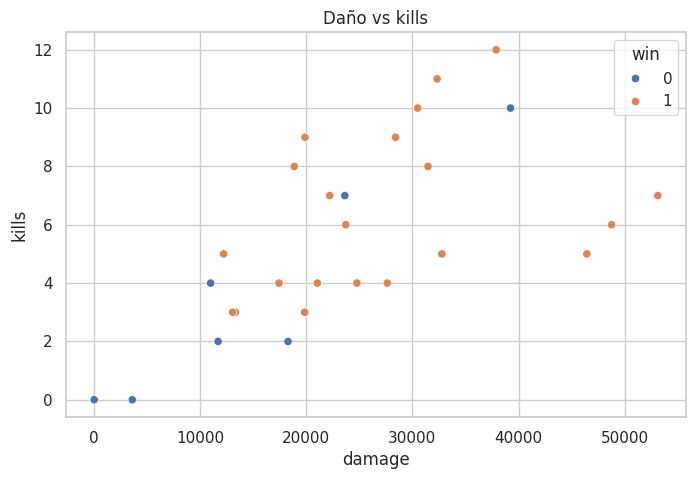

In [198]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="damage", y="kills", hue="win", data=df_yorick)

plt.title("Daño vs kills")

plt.show()

¿El jugador mejora o empeora en eliminaciones a medida que juega más partidas?

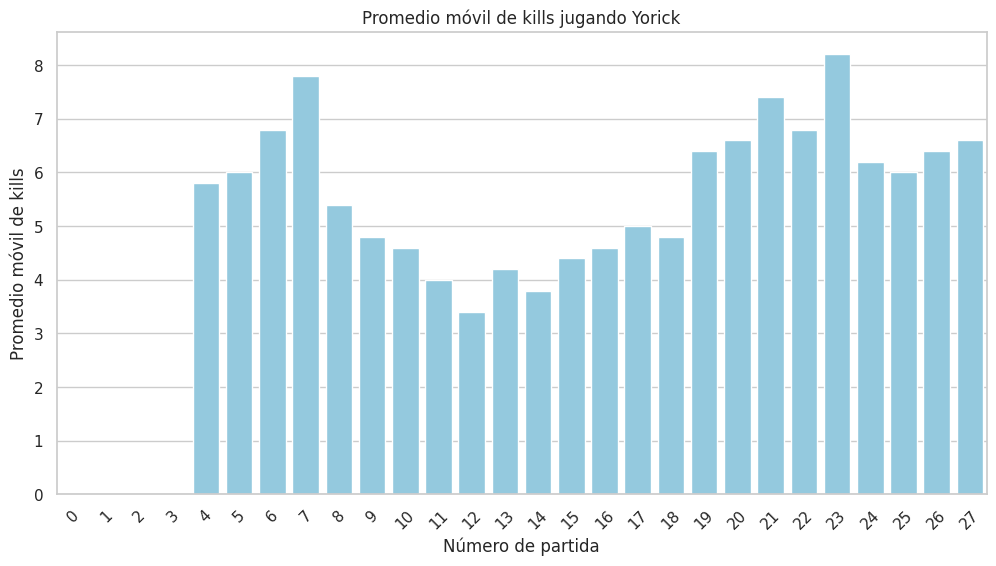

In [170]:
rolling_kills = df_yorick["kills"].rolling(5).mean()

plt.figure(figsize=(12,6))

sns.barplot(
    x=list(range(len(rolling_kills))),
    y=rolling_kills,
    color="skyblue"
)

plt.title("Promedio móvil de kills jugando Yorick")
plt.xlabel("Número de partida")
plt.ylabel("Promedio móvil de kills")

plt.xticks(rotation=45)

plt.show()

¿El control de visión influye en el resultado de las partidas?


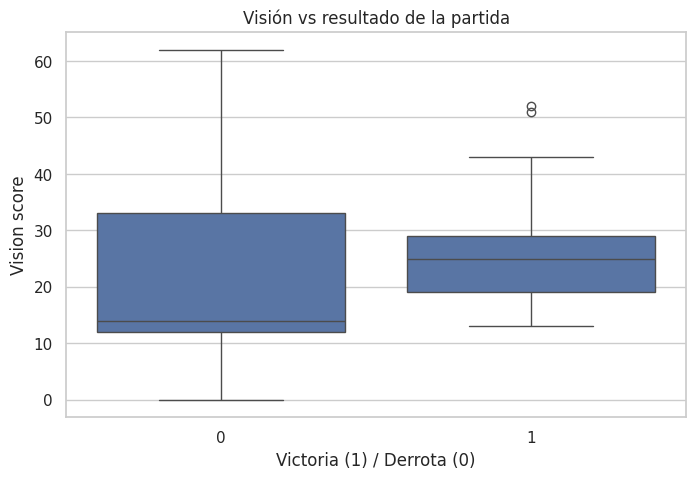

In [194]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="win",
    y="vision",
    data=df_yorick
)

plt.title("Visión vs resultado de la partida")
plt.xlabel("Victoria (1) / Derrota (0)")
plt.ylabel("Vision score")

plt.show()

¿Las muertes influyen en el resultado de las partidas?

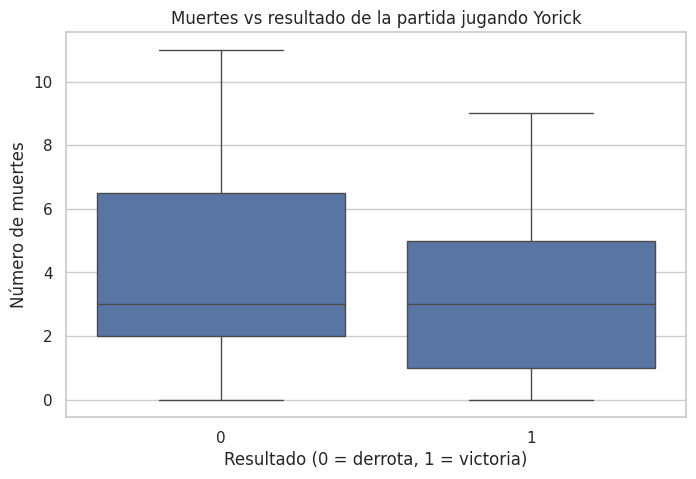

In [195]:
plt.figure(figsize=(8,5))

sns.boxplot(x="win", y="deaths", data=df_yorick)

plt.title("Muertes vs resultado de la partida jugando Yorick")
plt.xlabel("Resultado (0 = derrota, 1 = victoria)")
plt.ylabel("Número de muertes")

plt.show()

¿El farm (CS) influye en la probabilidad de victoria?

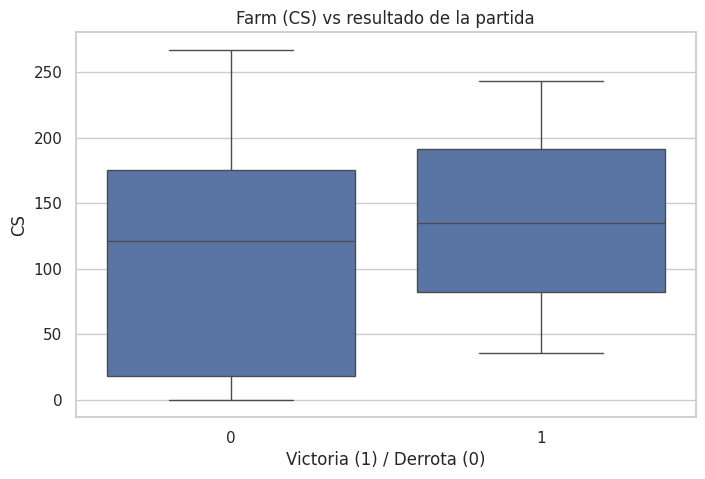

In [193]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="win",
    y="cs",
    data=df_yorick
)

plt.title("Farm (CS) vs resultado de la partida")
plt.xlabel("Victoria (1) / Derrota (0)")
plt.ylabel("CS")

plt.show()

¿El rendimiento del jugador mejora o empeora con el tiempo?

/tmp/ipykernel_1555/2741413564.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_yorick["game_number"] = range(len(df_yorick))


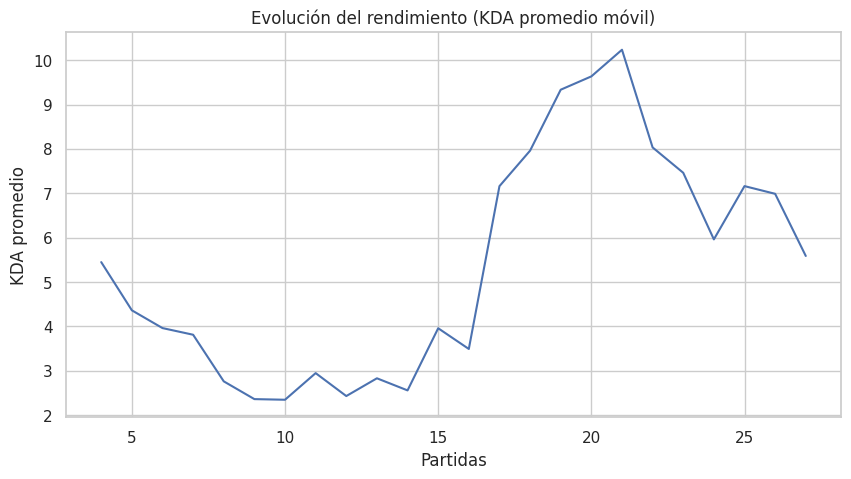

In [192]:
df_yorick["game_number"] = range(len(df_yorick))

rolling_kda = df_yorick["kda"].rolling(5).mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=df_yorick["game_number"],
    y=rolling_kda
)

plt.title("Evolución del rendimiento (KDA promedio móvil)")
plt.xlabel("Partidas")
plt.ylabel("KDA promedio")

plt.show()

¿Qué variables están más relacionadas con ganar partidas?

In [180]:
corr = df_yorick[["kills","deaths","assists","kda","damage","vision","cs","gold","win"]].corr()

win_corr = corr["win"].sort_values(ascending=False)

print(win_corr)

win        1.000000
gold       0.467565
assists    0.457069
kda        0.440486
damage     0.412178
kills      0.383409
cs         0.141511
vision     0.096938
deaths    -0.172893
Name: win, dtype: float64


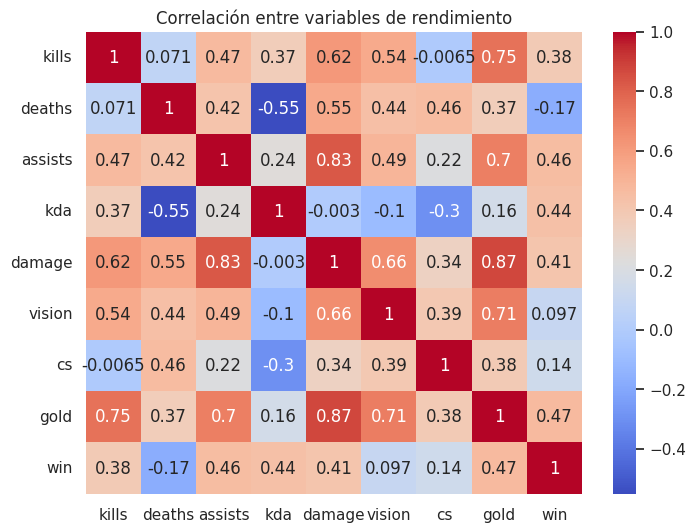

In [190]:
corr = df_yorick[[
    "kills",
    "deaths",
    "assists",
    "kda",
    "damage",
    "vision",
    "cs",
    "gold",
    "win"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre variables de rendimiento")

plt.show()

¿Qué factores debería mejorar el jugador para aumentar su probabilidad de victoria?

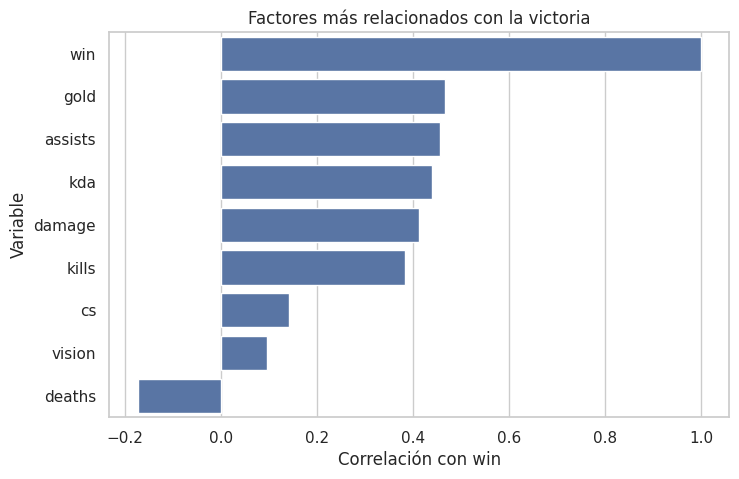

In [187]:
win_corr = corr["win"].sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=win_corr.values,
    y=win_corr.index
)

plt.title("Factores más relacionados con la victoria")
plt.xlabel("Correlación con win")
plt.ylabel("Variable")

plt.show()

¿Qué día rinde mejor jugando Yorick?

/tmp/ipykernel_1555/2454883127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_yorick["date"] = pd.to_datetime(df_yorick["date"])
/tmp/ipykernel_1555/2454883127.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_yorick["day"] = df_yorick["date"].dt.day_name()


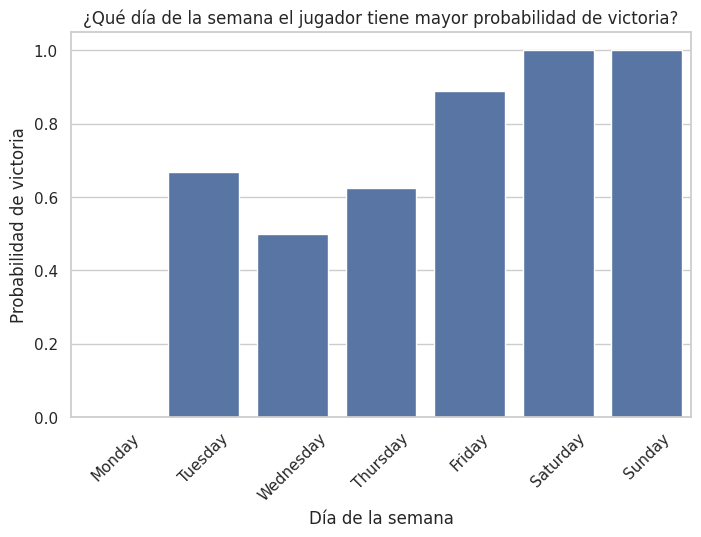

In [199]:
# Convertir la columna de fecha a formato datetime
df_yorick["date"] = pd.to_datetime(df_yorick["date"])

# Extraer el día de la semana
df_yorick["day"] = df_yorick["date"].dt.day_name()

# Calcular probabilidad de victoria por día
winrate_day = df_yorick.groupby("day")["win"].mean()

# Ordenar los días de la semana
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
winrate_day = winrate_day.reindex(order)

# Gráfica
plt.figure(figsize=(8,5))

sns.barplot(
    x=winrate_day.index,
    y=winrate_day.values
)

plt.title("¿Qué día de la semana el jugador tiene mayor probabilidad de victoria con Yorick?")
plt.xlabel("Día de la semana")
plt.ylabel("Probabilidad de victoria")

plt.xticks(rotation=45)

plt.show()

#¿Qué día tiene mayor probabilidad de victoria en general?

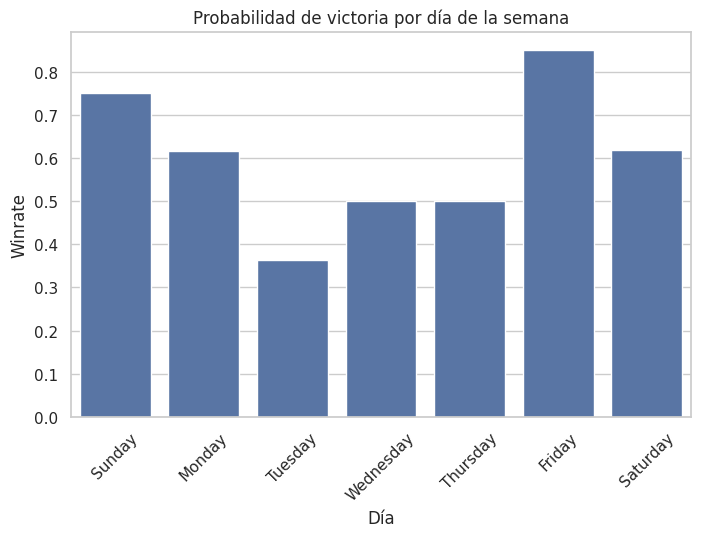

In [201]:
# Convertir fecha
df["date"] = pd.to_datetime(df["date"])

# Obtener día de la semana
df["day"] = df["date"].dt.day_name()

# Calcular winrate por día
winrate_day = df.groupby("day")["win"].mean()

# Orden correcto de días
order = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
winrate_day = winrate_day.reindex(order)

# Gráfica
plt.figure(figsize=(8,5))

sns.barplot(
    x=winrate_day.index,
    y=winrate_day.values
)

plt.title("Probabilidad de victoria por día de la semana")
plt.xlabel("Día")
plt.ylabel("Winrate")

plt.xticks(rotation=45)

plt.show()